In [2]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Research Agent 

*Next step in Deep Research is to gather the context collected in the research brief.*

Here is our overall research flow: ![alt text](image-1.png)

Research involves implementing strategies to collect information by synthesizing the request.
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) Agents work well for research because they can try different approaches and use what they learn along the way to decide what to do next.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **Query Generator (LLM)**: Analyzes the research brief and generates web search queries
2. **Web Search Tool**: Executes web search to fetch information based on the search queries. Summarizes information from each page.
3. **Research Compression Node**: Compresses research findings for efficient processing

![alt text](single_tool_call.png)

In [3]:
from utils import show_prompt

In [27]:
research_agent_prompt =  """Today's date is {date}. You are a research assistant conducting research on the user's input topic.

<Task>
Your job is to use web search tools to gather information about the user's input topic from the web. 
</Task>

<Available Tools>
You have access to web search tools:
1. **tavily_search**: For conducting web searches to gather information. You can search on any websites or databases that you think are relevant to the topic.
</Available Tools>

<Instructions>
Think like a human researcher. Complete your research with minimal iterations. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Generate multiple search queries to search for information** - Be specific and targeted in your queries.
3. **Use the tavily_search tool to perform web searches** - Use your generated queries to find relevant information.
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 2-3 queries maximum
- **Complex queries**: Use up to 4 queries maximum
</Hard Limits>
"""
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  Today's date is {date}. You are a research assistant conducting research on the user's input topic.            │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use web search tools to gather information about the user's input topic from the web.           │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to web search tools:                                                                           │
│  1. **tavily_search**: For conducting web searches to gather information. You can search on any websites or     │
│  databases that you think are relevant to the topic.                                                            │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher. Complete your research with minimal iterations. Follow these steps:             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Generate multiple search queries to search for information** - Be specific and targeted in your queries.  │
│  3. **Use the tavily_search tool to perform web searches** - Use your generated queries to find relevant        │
│  information.                                                                                                   │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 2-3 queries maximum                                                                  │
│  - **Complex queries**: Use up to 4 queries maximum                                                             │
│  </Hard Limits>                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

### State and Schemas

We'll create the agent state object.
1. **Researcher State**
2. **Researcher Output State**

In [28]:
"""
State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

### Web Summarization

We'll create a prompt that will be used to summarize the information from the searched web page.


In [29]:

summarize_webpage_prompt = """
You are an expert at summarizing the web content retrieved from the web search.You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that preserves the important information from the original web page. This summary will be used by a downstream research agent, so it's crucial to maintain the key details without losing essential information.

Here is the raw content of the webpage:

<webpage_content>
{webpage_content}
</webpage_content>

Please follow these guidelines to create your summary:

1. Identify and preserve the main topic or purpose of the webpage.
2. Retain key facts, statistics, and data points that are central to the content's message.
3. Keep important quotes from credible sources or experts.
4. Maintain the chronological order of events if the content is time-sensitive or historical.
5. Preserve any lists or step-by-step instructions if present.
6. Include relevant dates, names, and locations that are crucial to understanding the content.
7. Summarize lengthy explanations while keeping the core message intact.

When handling different types of content:

- For news articles: Focus on the who, what, when, where, why, and how.
- For scientific content: Preserve methodology, results, and conclusions.
- For opinion pieces: Maintain the main arguments and supporting points.
- For product pages: Keep key features, specifications, and unique selling points.

Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information.

Present your summary in the following format:

```
{{
   "summary": "Your summary here, structured with appropriate paragraphs or bullet points as needed",
   "key_excerpts": "First important quote or excerpt, Second important quote or excerpt, Third important quote or excerpt, ...Add more excerpts as needed, up to a maximum of 5"
}}
```

Here are two examples of good summaries:

Example 1 (for a news article):
```json
{{
   "summary": "On July 15, 2023, NASA successfully launched the Artemis II mission from Kennedy Space Center. This marks the first crewed mission to the Moon since Apollo 17 in 1972. The four-person crew, led by Commander Jane Smith, will orbit the Moon for 10 days before returning to Earth. This mission is a crucial step in NASA's plans to establish a permanent human presence on the Moon by 2030.",
   "key_excerpts": "Artemis II represents a new era in space exploration, said NASA Administrator John Doe. The mission will test critical systems for future long-duration stays on the Moon, explained Lead Engineer Sarah Johnson. We're not just going back to the Moon, we're going forward to the Moon, Commander Jane Smith stated during the pre-launch press conference."
}}
```

Example 2 (for a scientific article):
```json
{{
   "summary": "A new study published in Nature Climate Change reveals that global sea levels are rising faster than previously thought. Researchers analyzed satellite data from 1993 to 2022 and found that the rate of sea-level rise has accelerated by 0.08 mm/year² over the past three decades. This acceleration is primarily attributed to melting ice sheets in Greenland and Antarctica. The study projects that if current trends continue, global sea levels could rise by up to 2 meters by 2100, posing significant risks to coastal communities worldwide.",
   "key_excerpts": "Our findings indicate a clear acceleration in sea-level rise, which has significant implications for coastal planning and adaptation strategies, lead author Dr. Emily Brown stated. The rate of ice sheet melt in Greenland and Antarctica has tripled since the 1990s, the study reports. Without immediate and substantial reductions in greenhouse gas emissions, we are looking at potentially catastrophic sea-level rise by the end of this century, warned co-author Professor Michael Green."  
}}
```

Remember, your goal is to create a summary that can be easily understood and utilized by a downstream research agent while preserving the most critical information from the original webpage.

Today's date is {date}.
"""

show_prompt(summarize_webpage_prompt, "Summarize Webpage")

╭─────────────────────────────────────────────── Summarize Webpage ───────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│  You are an expert at summarizing the web content retrieved from the web search.You are tasked with             │
│  summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that    │
│  preserves the important information from the original web page. This summary will be used by a downstream      │
│  research agent, so it's crucial to maintain the key details without losing essential information.              │
│                                                                                                                 │
│  Here is the raw content of the webpage:                                                                        │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  Please follow these guidelines to create your summary:                                                         │
│                                                                                                                 │
│  1. Identify and preserve the main topic or purpose of the webpage.                                             │
│  2. Retain key facts, statistics, and data points that are central to the content's message.                    │
│  3. Keep important quotes from credible sources or experts.                                                     │
│  4. Maintain the chronological order of events if the content is time-sensitive or historical.                  │
│  5. Preserve any lists or step-by-step instructions if present.                                                 │
│  6. Include relevant dates, names, and locations that are crucial to understanding the content.                 │
│  7. Summarize lengthy explanations while keeping the core message intact.                                       │
│                                                                                                                 │
│  When handling different types of content:                                                                      │
│                                                                                                                 │
│  - For news articles: Focus on the who, what, when, where, why, and how.                                        │
│  - For scientific content: Preserve methodology, results, and conclusions.                                      │
│  - For opinion pieces: Maintain the main arguments and supporting points.                                       │
│  - For product pages: Keep key features, specifications, and unique selling points.                             │
│                                                                                                                 │
│  Your summary should be significantly shorter than the original content but comprehensive enough to stand       │
│  alone as a source of information.                                                                              │
│                                                                                                                 │
│  Present your summary in the following format:        

## Helper Utility Functions 

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing


In [30]:

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output



### Tools

#### Tavily SDK Integration
**tavily search tool**: Tool to perform web searches.
We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance


In [31]:
# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization

#### 2. Research Result Compression  

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [32]:

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model


from prompts import compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize models
model = init_chat_model(model="openai:gpt-4.1-mini")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("generate_query", llm_call)
agent_builder.add_node("web_search_tool", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "generate_query")
agent_builder.add_edge("generate_query", "web_search_tool")
agent_builder.add_edge("web_search_tool","compress_research")
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

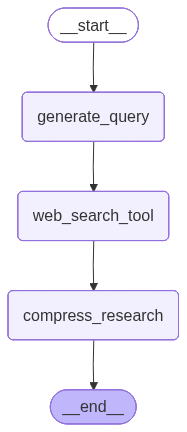

In [33]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [34]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. 
My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""


result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance.         │
│ My goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their     │
│ ambiance,                                                                                                       │
│ including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified          │
│ preferences                                                                                                     │
│ regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities,  │
│ so these                                                                                                        │
│ should be considered flexible unless they are relevant to ambiance. Please prioritize information from official │
│ coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible   │
│ local                                                                                                           │
│ publications. The research should be current as of October 2025..                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shops Seattle ambiance interior design atmosphere comfort vibe 2025"                    │
│ }                                                                                                               │
│    ID: call_15wxaasusHZL9cml9ezp9FbV                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "top coffee shops Seattle ambiance review Google Yelp TripAdvisor 2025"                              │
│ }                                                                                                               │
│    ID: call_qXQN7pKB3WegyNIZp6iwgYl4                                                                            │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "Seattle coffee shops ambiance unique atmosphere local publications 2025"                            │
│ }                                                                                                               │
│    ID: call_W6PWnAb7SQEOCt7BDVvPil9x                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Seattle Coffee Guide 2025: The Best Cafes for Work, Tourists ... ---                              │
│ URL:                                                                                                            │
│ https://www.junky-traveler.com/post/seattle-coffee-guide-2025-the-best-cafes-for-work-tourists-instagram-lovers │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage provides a comprehensive 2025 Seattle Coffee Guide, highlighting the city's rich coffee culture     │
│ beyond being the birthplace of Starbucks. It curates a list of favored local cafés known for specialty coffee,  │
│ comfortable workspaces, and photogenic interiors, catering to coffee lovers, digital nomads, and aesthetic café │
│ seekers. Key featured work-friendly spots include Olympia Coffee (Downtown), Zeitgeist Coffee (Pioneer Square), │
│ URL Coffee (First Hill), Chocolati Café (Greenwood), Caffè Umbria (Pioneer Square), 203° Fahrenheit Coffee      │
│ Company (South Lake Union), Empire Coffee (Lower Queen Anne), The Burnt Coffee Company, Seasmith (Capitol       │
│ Hill), and Burien Press (Burien). For tourists and first-time visitors, notable cafes are Storyville Coffee     │
│ Company (Pike Place Market), Victory Coffee (Downtown), Starbucks Reserve Roastery (Capitol Hill), Starbucks    │
│ First Store (Pike Place), and Café Hagen (South Lake Union). The guide also highlights cafés with               │
│ Instagram-worthy vibes such as Olympia Coffee, Caffè Umbria, 203° Fahrenheit Coffee Company, and Café Hagen.    │
│ Additional suggestions include Anchorhead Coffee, Root, Cardoon, Espresso Vivace, Kaladi Brothers Coffee, Zoka  │
│ Coffee, and Cafe Allegro. Each listing includes description of atmosphere, specialty offerings, hours, and      │
│ location, catering to diverse preferences for work, leisure, and socializing in Seattle's vibrant coffee scene. │
│ The site also features related posts on Seattle attractions and tours, authored by traveler Ali Koklu.          │
│ </summary>                                                                                                      │
│                                                                                                                 │
│ <key_excerpts>                                                                                                  │
│ Seattle is more than just the birthplace of Starbucks—it’s one of the best cities in the U.S. for coffee        │
│ lovers, digital nomads, and aesthetic café seekers.; This 2025 Seattle coffee guide features handpicked local   │
│ cafés known for specialty coffee, cozy workspaces, and beautifully designed interiors.; Olympia Coffee blends   │
│ vibrant ambiance with exceptional quality, making for a comfortable and photogenic workspace.; Starbucks        │
│ Reserve Roastery is a must-see for Seattle coffee pilgrims, offering rare brews, on-site roasting, and          │
│ immersive experiences.; Planning your Seattle coffee crawl? Whether you’re here to work, wander, or snap, this  │
│ guide keeps your cup full with local recommendations th

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Best Coffee Shops Seattle, WA - Last Updated October 2025 - Yelp ---                              │
│ URL: https://m.yelp.com/search?find_desc=Best+Coffee+Shops&find_loc=Seattle%2C+WA                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Best Coffee Shops Near Seattle, Washington ; 1. Storyville Coffee Company · (2.5k reviews). 1.2 mi ; 2. Moore   │
│ Coffee Shop · (1.4k reviews). 1.0 mi ; 3. Anchorhead                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Best Coffee Seattle, WA - Last Updated October 2025 - Yelp ---                                    │
│ URL: https://m.yelp.com/search?find_desc=Best+Coffee&find_loc=Seattle%2C+WA                                     │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 1. Storyville Coffee Company · (2.5k reviews). 1.2 mi ; 2. Drip Drip Coffeehouse · (163 reviews). 1.7 mi ; 3.   │
│ Victrola Coffee Roasters · (958 reviews). 1.1 mi ; 4.                                                           │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: TOP 10 BEST Aesthetic Cafe in Seattle, WA - Updated 2025 - Yelp ---                               │
│ URL: https://www.yelp.com/search?find_desc=Aesthetic+Cafe&find_loc=Seattle%2C+WA                                │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Aesthetic Cafe Near Seattle, Washington ; 1. Santo Coffee · (212 reviews) · 1325 NE 65th St,        │
│ Seattle, WA 98115. (206) 403-1678 ; 2. Phe · (166 reviews).                                                     │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: TOP 10 BEST Coffee Shops With Ambience in Seattle, WA - Yelp ---                                  │
│ URL: https://www.yelp.com/search?find_desc=Coffee+Shops+With+Ambience&find_loc=Seattle%2C+WA                    │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Coffee Shops With Ambience in Seattle, WA - Last Updated October 2025 - Yelp - Storyville Coffee    │
│ Company, Sugar Bakery, Drip Drip Coffeehouse,                                                                   │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Unique Cafes with Ambiance in Seattle - Lemon8-app ---                                            │
│ URL: https://www.lemon8-app.com/experience/seattle-cafe-with-unique-ambiance?region=us                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Seattle is renowned for its vibrant café culture, where each spot offers a unique ambiance that caters to       │
│ various tastes and preferences.                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: 27 Best Coffee Shops in Seattle, WA For a Caffeine Fix ---                                        │
│ URL: https://www.emeraldpalate.com/best-coffee-shops-in-seattle/                                                │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage presents a curated list of the 27 best coffee shops in Seattle, WA, highlighting diverse venues     │
│ recognized for their unique coffee offerings, ambiance, and speciality brews. It emphasizes Seattle as a        │
│ prominent city for coffee culture. Each featured coffee shop includes details such as neighborhood location,    │
│ website links, and what makes them stand out—for example, Ghost Note Coffee in Capitol Hill is known for        │
│ creative non-alcoholic cocktail-style coffees, while Bo

In [35]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 1 Query: best coffee shops Seattle ambiance interior design atmosphere comfort vibe 2025 [1]                      
 2 Query: top coffee shops Seattle ambiance review Google Yelp TripAdvisor 2025 [4]                                
 3 Query: Seattle coffee shops ambiance unique atmosphere local publications 2025 [7]                              

Fully Comprehensive Findings                                                                                       

 • The webpage provides a comprehensive 2025 Seattle Coffee Guide, highlighting the city's rich coffee culture     
   beyond being the birthplace of Starbucks. It curates a list of favored local cafés known for specialty coffee,  
   comfortable workspaces, and photogenic interiors, catering to coffee lovers, digital nomads, and aesthetic café 
   seekers. Key featured work-friendly spots include Olympia Coffee (Downtown), Zeitgeist Coffee (Pioneer Square), 
   URL Coffee (First Hill), Chocolati Café (Greenwood), Caffè Umbria (Pioneer Square), 203° Fahrenheit Coffee      
   Company (South Lake Union), Empire Coffee (Lower Queen Anne), The Burnt Coffee Company, Seasmith (Capitol Hill),
   and Burien Press (Burien). For tourists and first-time visitors, notable cafes are Storyville Coffee Company    
   (Pike Place Market), Victory Coffee (Downtown), Starbucks Reserve Roastery (Capitol Hill), Starbucks First Store
   (Pike Place), and Café Hagen (South Lake Union). The guide also highlights cafés with Instagram-worthy vibes    
   such as Olympia Coffee, Caffè Umbria, 203° Fahrenheit Coffee Company, and Café Hagen. Additional suggestions    
   include Anchorhead Coffee, Root, Cardoon, Espresso Vivace, Kaladi Brothers Coffee, Zoka Coffee, and Cafe        
   Allegro. Each listing includes description of atmosphere, specialty offerings, hours, and location, catering to 
   diverse preferences for work, leisure, and socializing in Seattle's vibrant coffee scene. The site also features
   related posts on Seattle attractions and tours, authored by traveler Ali Koklu.                                 
   Key excerpts:                                                                                                   
    • Seattle is more than just the birthplace of Starbucks—it's one of the best cities in the U.S. for coffee     
      lovers, digital nomads, and aesthetic café seekers.                                                          
    • This 2025 Seattle coffee guide features handpicked local cafés known for specialty coffee, cozy workspaces,  
      and beautifully designed interiors.                                                                          
    • Olympia Coffee blends vibrant ambiance with exceptional quality, making for a comfortable and photogenic     
      workspace.                                                                                                   
    • Starbucks Reserve Roastery is a must-see for Seattle coffee pilgrims, offering rare brews, on-site roasting, 
      and immersive experiences.                                                                                   
    • Planning your Seattle coffee crawl? Whether you're here to work, wander, or snap, this guide keeps your cup  
      full with local recommendations that are actually worth your time. [1]                                       
 • Top 10 Best Coffee Shops With Ambience Near Seattle, Washington:                                                
    1 Storyville Coffee Company                                                                                    
    2 Sugar Bakery                                                                                                 
    3 Drip Drip Coffeehouse                                                                                        
    4 Bonito Cafe y [2]                              